In [1]:
using Revise
using TTNKit
using Test
using ITensors
using PyPlot
using LinearAlgebra
using LaTeXStrings
using ProfileView
using Polynomials
using KrylovKit
using Printf, BenchmarkTools, Random

In [19]:
begin
    include("ttn.jl")
end

"fin"

In [2]:
mutable struct EnergyObserver <: AbstractObserver
    en_vec::Vector{Float64}
    EnergyObserver() = new(Float64[])
end

function ITensors.measure!(ob::EnergyObserver; kwargs...)
    sh = kwargs[:sweep_handler]
    push!(ob.en_vec, sh.current_energy)
end

In [3]:
let 
    j = Index(QN(0) => 2, QN(1) => 2)
    k = Index(QN(1) => 2, QN(2) => 3)
    
    A = randomITensor(QN(-1), (j), dag(k))
    B = randomITensor(TTNKit.shift_qn((j), flux(A)), dag(k))
    #println(A)
    #println(B)
    
    #TTNKit.shift_qn((j), flux(A))
    sim(j; dir = ITensors.In)
end

(dim=4|id=274) <In>
 1: QN(0) => 2
 2: QN(1) => 2

In [4]:
let
    s = siteind("Boson", conserve_qns = true)
    state(s, "0")
end

ITensor ord=1
(dim=2|id=862|"Boson,Site") <Out>
 1: QN("Number",0) => 1
 2: QN("Number",1) => 1
NDTensors.BlockSparse{Float64, Vector{Float64}, 1}

In [5]:
function hcb_ham(t, Vj, phi, lat)
    ampo = OpSum()
	    
	for p in TTNKit.coordinates(lat)
	    ampo += Vj[p[1],p[2]], "N", p
	end
    for bond in TTNKit.nearest_neighbours(lat, collect(eachindex(lat)))
	    b1 = TTNKit.coordinate(lat, first(bond))
	    b2 = TTNKit.coordinate(lat, last(bond))
        
        if b1[1] == b2[1]
            # bond along x, no phase
            ϕ_b = ComplexF64(1)
        else
            ϕ_b = exp(im * phi*b1[1])
        end
	    ampo += -t*ϕ_b, "Adag", b1, "A", b2
	    ampo += -t*conj(ϕ_b), "Adag", b2, "A", b1
	end
	return ampo
end

hcb_ham (generic function with 1 method)

In [6]:
function v_central(sz, Vj)
    V = zeros(sz)
    V[sz[1]÷2, sz[2]÷2] = Vj
    V[sz[1]÷2, sz[2]÷2 + 1] = Vj
    V[sz[1]÷2 + 1, sz[2]÷2] = Vj
    V[sz[1]÷2 + 1, sz[2]÷2 + 1] = Vj
    return V
end
no_v(sz) = zeros(sz)    

no_v (generic function with 1 method)

In [7]:
let
    sz = (16,16)
    Vj = v_central(sz, 1.0)
    #heatmap(Vj, c = :acton)
end

16×16 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

In [29]:
begin n_layer = 4; nd = TTNKit.ITensorNode; conserve_qns = true; maxdims = 40

    t = 1; phi = 0.15*2*π; Nbosons = 12; vpinning = 2.5
    max_occ = Int(ceil(Nbosons/(2^n_layer))+1)
    net = TTNKit.BinaryRectangularNetwork(n_layer, nd, "Boson"; conserve_qns = conserve_qns,dim=max_occ+1)
    lat = TTNKit.physical_lattice(net)
    Vj  = v_central(size(lat), vpinning)
    
    
    
    #states = vcat(repeat(["0"], TTNKit.number_of_sites(net)-Nbosons), repeat(["1"], Nbosons)...)
    #states = states[randperm(length(states))]
    states = fill_states(Nbosons,2^n_layer,max_occ)
    ttn0 = TTNKit.ProductTreeTensorNetwork(net, states)
    
   
    
    expander = TTNKit.DefaultExpander(0.2)
end

TTNKit.DefaultExpander(0.2, 1)

In [30]:
begin
    
    #mpo = TTNKit.TPO(hcb_ham(t, no_v(size(lat)), phi, lat), lat)
    ham_op = get_hofstadter_interacting_hamilt(net,t,phi; if_periodic=false,if_chem=false,if_onsite=false,no_magF=true)
    
    mpo = TTNKit.TPO(ham_op,lat)
    obs_nv = EnergyObserver()
    maxdims_ar = [10,10, 20, 20,maxdims]#[50, 50, 50, 80, 80, 80, maxdims]
    #observer = obs_nv,
    ttn = TTNKit.adjust_tree_tensor_dimensions(ttn0, 2*maxdims; reorthogonalize = true)
    sp_nv = TTNKit.dmrg(ttn, mpo, number_of_sweeps = 10, outputlevel = 2, 
        expander = expander, maxdims =maxdims_ar ,
        noise =0.0)#[0.1,0.1,0.01,0.01,0,01,0])
    #expander = TTNKit.DefaultExpander(0.1)
 
    println("=======================================================")
    
     
    #linkdims1 = map(pos -> maximum(dims(sp_nv.ttn[pos])),TTNKit.NodeIterator(net))
    #scatter(linkdims1, label = "NV")
    #mpo = TTNKit.TPO(hcb_ham(t, Vj, phi, lat), lat)
       #linkdims1 = map(pos -> maximum(dims(sp.ttn[pos])),TTNKit.NodeIterator(net))
    #sp = TTNKit.dmrg(sp.ttn, mpo, number_of_sweeps = 2, outputlevel = 2,
    #    expander = expander, maxdims = maxdims, observer = obs)
    
    #obs_v = EnergyObserver()
    #sp_v  = TTNKit.dmrg(sp_nv.ttn, mpo, number_of_sweeps = 3, outputlevel = 2, 
    #    expander = expander, maxdims = 50, observer = obs_v)
    #sp_v  = TTNKit.dmrg(sp_v.ttn, mpo, number_of_sweeps = 3, outputlevel = 2, 
    #    expander = expander, maxdims = 100, observer = obs_v)
    #sp_v  = TTNKit.dmrg(sp_v.ttn, mpo, number_of_sweeps = 4, outputlevel = 2, 
    #    expander = expander, maxdims = maxdims, observer = obs_v)
    
end

reorthogonalize = true
Start sweep number 1
Finsihed sweep 1. Needed Time 1.143s
	Current energy: -31.841035.
	Truncated Weigth: 1.056e-03. Maximal bond dim = 10

Start sweep number 2
Finsihed sweep 2. Needed Time 0.760s
	Current energy: -31.845396.
	Truncated Weigth: 4.723e-04. Maximal bond dim = 10

Start sweep number 3
Finsihed sweep 3. Needed Time 0.873s
	Current energy: -32.073055.
	Truncated Weigth: 8.866e-05. Maximal bond dim = 20

Start sweep number 4
Finsihed sweep 4. Needed Time 1.001s
	Current energy: -32.079703.
	Truncated Weigth: 6.281e-05. Maximal bond dim = 20

Start sweep number 5
Finsihed sweep 5. Needed Time 1.312s
	Current energy: -32.106526.
	Truncated Weigth: 7.551e-06. Maximal bond dim = 40

Start sweep number 6
Finsihed sweep 6. Needed Time 1.542s
	Current energy: -32.109192.
	Truncated Weigth: 9.544e-06. Maximal bond dim = 40

Start sweep number 7
Finsihed sweep 7. Needed Time 1.670s
	Current energy: -32.109208.
	Truncated Weigth: 1.091e-05. Maximal bond dim = 4

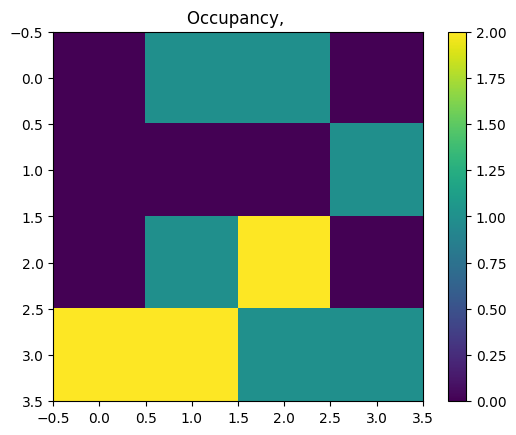

4×4 Matrix{Float64}:
 3.33525e-32  1.0          1.0          4.04955e-30
 9.08902e-32  1.71331e-32  4.35779e-30  1.0
 7.94369e-29  1.0          2.0          6.08664e-30
 2.0          2.0          1.0          1.0

In [32]:
get_occupancy(ttn)

Start sweep number 1
Finsihed sweep 1. Needed Time 100.367s
	Current energy: -39.442639.
	Truncated Weigth: 2.960e-05. Maximal bond dim = 10

Start sweep number 2
Finsihed sweep 2. Needed Time 29.103s
	Current energy: -42.906634.
	Truncated Weigth: 2.750e-04. Maximal bond dim = 10

Start sweep number 3
Finsihed sweep 3. Needed Time 38.995s
	Current energy: -43.128561.
	Truncated Weigth: 1.500e-06. Maximal bond dim = 40

Start sweep number 4
Finsihed sweep 4. Needed Time 61.759s
	Current energy: -43.164780.
	Truncated Weigth: 1.528e-05. Maximal bond dim = 40

Start sweep number 5
Finsihed sweep 5. Needed Time 63.493s
	Current energy: -43.168511.
	Truncated Weigth: 2.500e-05. Maximal bond dim = 40

Start sweep number 6
Finsihed sweep 6. Needed Time 63.064s
	Current energy: -43.169485.
	Truncated Weigth: 2.704e-05. Maximal bond dim = 40

Start sweep number 7
Finsihed sweep 7. Needed Time 64.212s
	Current energy: -43.169949.
	Truncated Weigth: 2.740e-05. Maximal bond dim = 40

Start sweep 

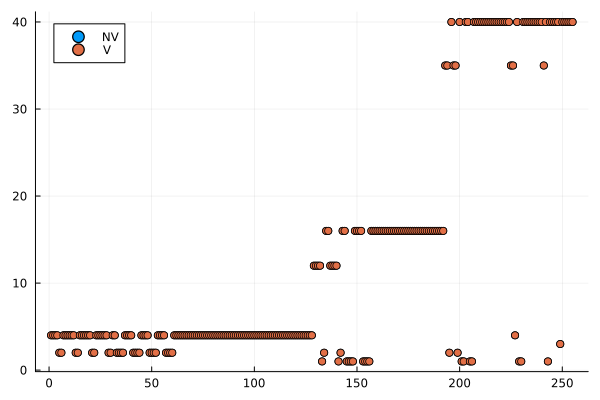

In [50]:
begin
    obs_v = EnergyObserver()
    mpo = TTNKit.TPO(hcb_ham(t, Vj, phi, lat), lat)
    maxdims_ar = [10,10,maxdims]#[50, 50, 50, 80, 80, 80, maxdims]
    sp_v  = TTNKit.dmrg(ttn, mpo, number_of_sweeps = 10, outputlevel = 2, 
        expander = expander, maxdims = maxdims_ar, observer = obs_v,
        noise = 0.0)#[0.1,0.1,0.01,0.01,0,01,0])
    
    println("=======================================================")
    
     
    linkdims2 = map(pos -> maximum(dims(sp_v.ttn[pos])),TTNKit.NodeIterator(net))
    scatter(linkdims1, label = "NV")
    scatter!(linkdims2, label = "V")
end

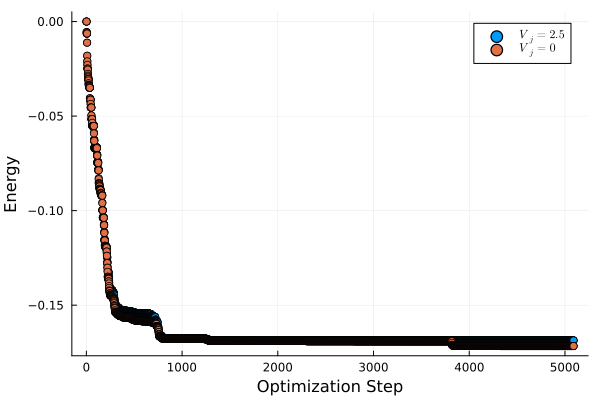

In [51]:
pl = plot()
plot!(1:length(obs_v.en_vec), obs_v.en_vec./TTNKit.number_of_sites(lat), seriestype = :scatter, label = L"V_j = %$(vpinning)")
plot!(1:length(obs_nv.en_vec), obs_nv.en_vec./TTNKit.number_of_sites(lat), seriestype = :scatter, label = L"V_j = 0")
xlabel!("Optimization Step")
ylabel!("Energy")

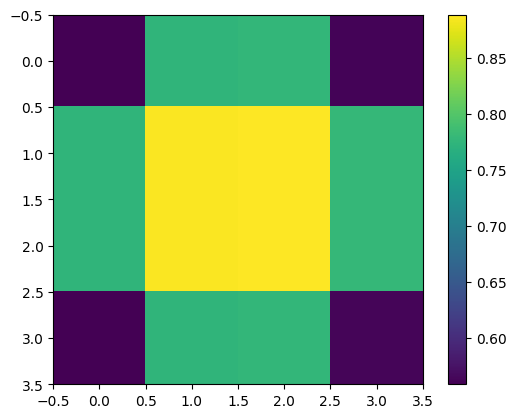

PyObject <matplotlib.colorbar.Colorbar object at 0x7f00169efa60>

In [33]:
#exp_n_v = real.(TTNKit.expect(sp_v.ttn, "N"))
exp_n_nv = real.(TTNKit.expect(sp_nv.ttn, "N"))
#pl1 = imshow(exp_n_v)
pl2 = imshow(exp_n_nv)
colorbar()
#plot(pl1, pl2)

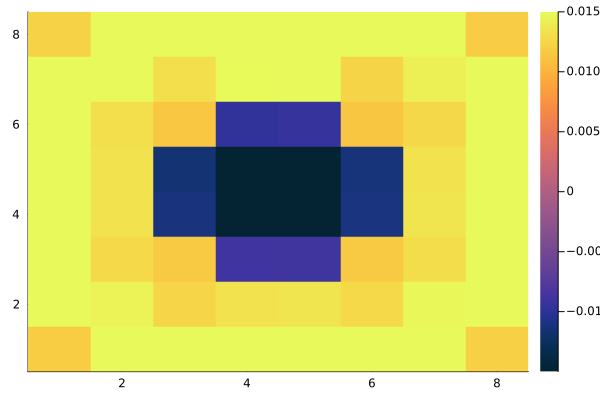

In [47]:
heatmap(exp_n_v .- exp_n_nv, c = :thermal, clims = (-0.015, 0.015))

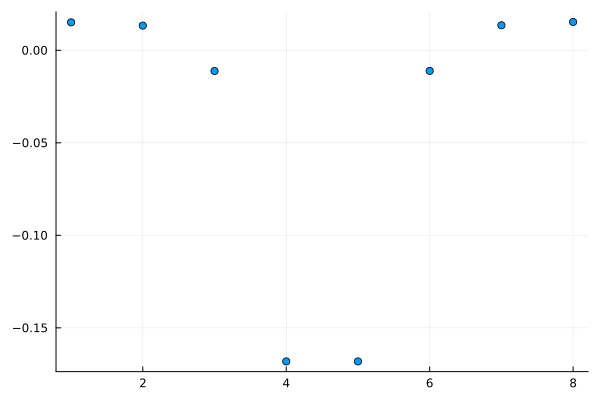

In [43]:
let
    exp_n_diff = exp_n_v .- exp_n_nv
    scatter(exp_n_diff[4,:], label = false)
end

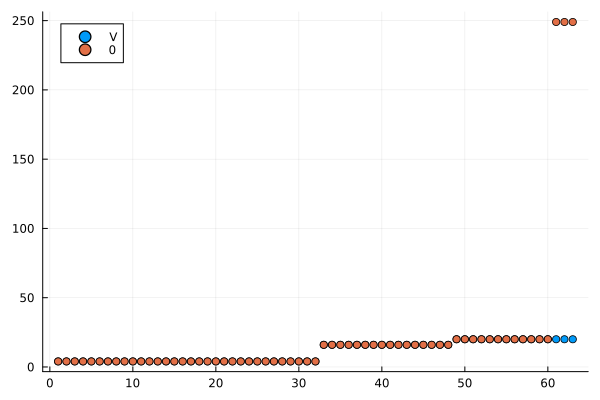

In [26]:
let
    linkdims1 = map(pos -> maximum(dims(sp_v.ttn[pos])),TTNKit.NodeIterator(net))
    linkdims2 = map(pos -> maximum(dims(sp_nv.ttn[pos])),TTNKit.NodeIterator(net))
    scatter(linkdims1, label = "V")
    scatter!(linkdims2, label = "0")
end    